In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/vbordalo/Communities-Crime/master/communities.data"
df = pd.read_csv(url, header=None, na_values=["?"])

print(df.shape)
df.head()

(1994, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [2]:
df_model = df.copy()

# Drop ID columns (first 5 columns)
df_model = df_model.drop(columns=[0,1,2,3,4])

df_model.head()

,5,6,7,8,9,10,11,12,13,14,...,118,119,120,121,122,123,124,125,126,127
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


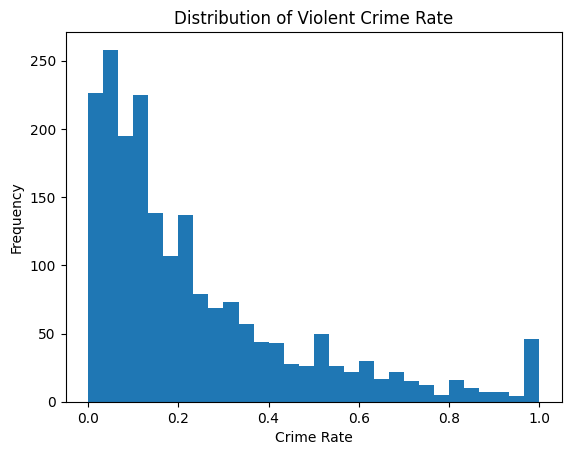

In [3]:
import matplotlib.pyplot as plt

target = df_model.columns[-1]  # last column is target

plt.hist(df_model[target].dropna(), bins=30)
plt.title("Distribution of Violent Crime Rate")
plt.xlabel("Crime Rate")
plt.ylabel("Frequency")

plt.savefig("target_distribution.png")
plt.show()

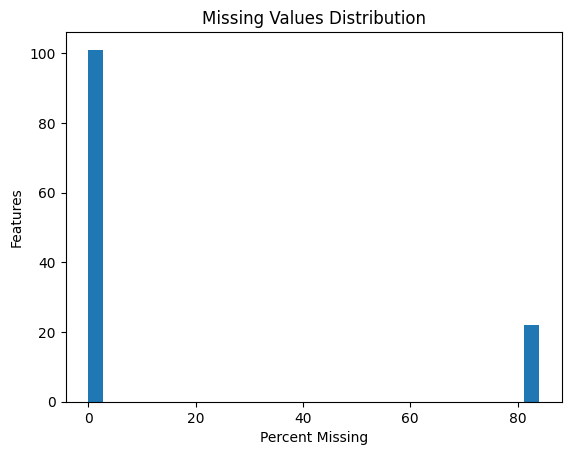

In [4]:
missing_pct = df_model.isna().mean() * 100

plt.hist(missing_pct, bins=30)
plt.title("Missing Values Distribution")
plt.xlabel("Percent Missing")
plt.ylabel("Features")

plt.savefig("missing_values.png")
plt.show()

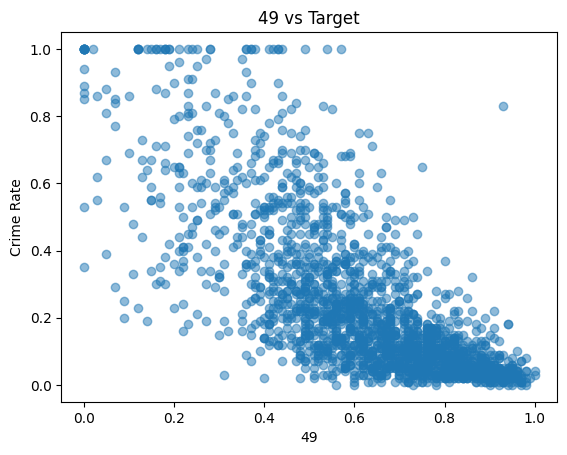

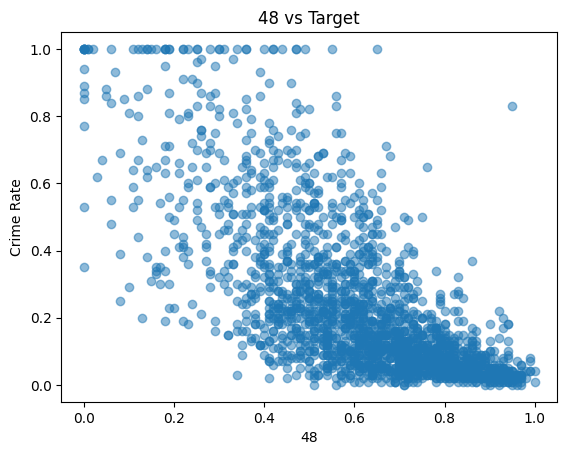

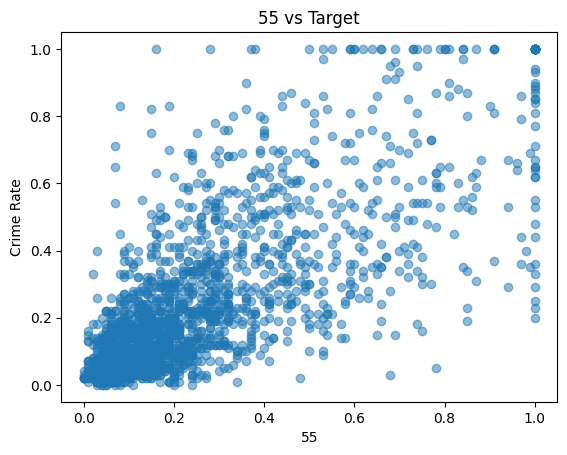

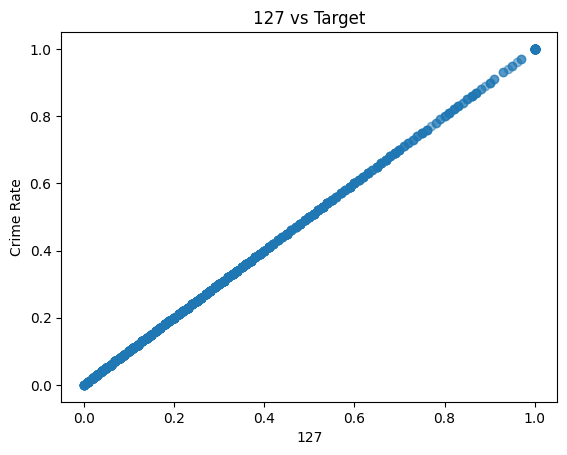

In [5]:
corr = df_model.corr(numeric_only=True)[target].sort_values()

features = list(corr.head(2).index) + list(corr.tail(2).index)

for col in features:
    plt.scatter(df_model[col], df_model[target], alpha=0.5)
    plt.title(f"{col} vs Target")
    plt.xlabel(col)
    plt.ylabel("Crime Rate")
    plt.show()

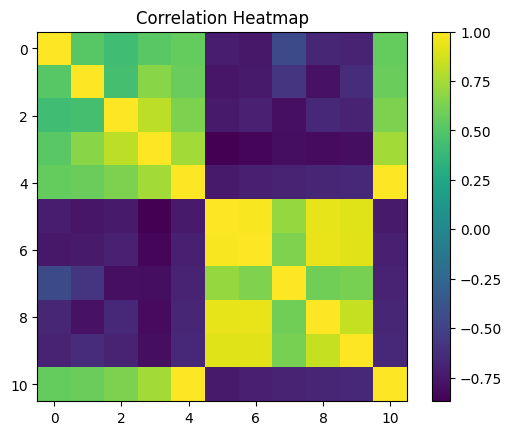

In [6]:
top_features = list(corr.tail(5).index) + list(corr.head(5).index)
top_features.append(target)

corr_matrix = df_model[top_features].corr()

plt.imshow(corr_matrix)
plt.colorbar()
plt.title("Correlation Heatmap")

plt.show()